In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import matplotlib
import pickle
import os
import glob

import pingouin as pg

from sklearn.metrics.pairwise import euclidean_distances
import statsmodels.api as sm
from statsmodels.formula.api import ols

from statsmodels.stats.multicomp import pairwise_tukeyhsd

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'


In [ ]:
# set directories and load data
basedir = '/path/to/pain-induced-manifold-changes'
datdir = os.path.join(basedir, 'data')


file = os.path.join(datdir, 'pain-induced-manifold-changes_10categ_data_prep_rsa_manifold.pickle')
with open(file, 'rb') as f:
    dat_all = pickle.load(f)
    
sub_ids = list(dat_all.keys())

categ_fname = os.path.join(datdir, 'category_names.pickle')
with open(categ_fname, 'rb') as f:
    categ_names = pickle.load(f)



In [9]:
# Perform RSA - based on image trials

rois = ['V1', 'V2', 'hV4', 'LO']
levels = [0, 1, 2]
cond_names = ['Warmth', 'LowHeat', 'HighHeat']
categ_order = ['bird', 'insect', 'reptile', 'seacreature', 'wildcat', 'clothes', 'furniture', 'instrument', 'meal', 'transport']


within_corr_df = pd.DataFrame({'Subject': [],
                               'ROI': [],
                               'Condition': [],
                               'Category': [],
                               'corr_within': []})
btw_corr_df = pd.DataFrame({'Subject': [],
                            'ROI': [],
                            'Condition': [],
                            'Category1': [],
                            'Category2': [],
                            'corr_btw': []})
                            
for sub in sub_ids: # loop through subjects
 
    sub_dat = dat_all[sub]
    
    for reg in rois: # loop through ROIs
     
        dat_temp = sub_dat[reg]
    
      
        for cond in levels: # loop through heat levels

            print(f'Working on {sub} | {reg} | {cond_names[cond]}')
            dat = dat_temp[cond]
            
            mean_repre = {}
            for cat_n, cat in enumerate(categ_names): # find mean representation of each category

                mean_repre_temp = np.mean(dat[cat_n,:,:],axis=1)
                mean_repre[cat] = mean_repre_temp
            
            # RSA between categories - using categ order for easier visualisation of animate vs. inanimate
            for cat1_n, cat1 in enumerate(categ_order):
                for cat2_n, cat2 in enumerate(categ_order):
                    if cat1_n<cat2_n:
                        btw_corr_temp = np.corrcoef(mean_repre[cat1], mean_repre[cat2])[0][1]
                        
                        btw_corr_df_temp = pd.DataFrame({'Subject': [sub],
                                                         'ROI': [reg],
                                                         'Condition': [cond_names[cond]],
                                                         'Category1': [cat1],
                                                         'Category2': [cat2],
                                                         'corr_btw': [btw_corr_temp]})
                        btw_corr_df = pd.concat([btw_corr_df, btw_corr_df_temp],ignore_index=True)
                

Working on pacman09 | V1 | Warmth
Working on pacman09 | V1 | LowHeat
Working on pacman09 | V1 | HighHeat
Working on pacman09 | V2 | Warmth
Working on pacman09 | V2 | LowHeat
Working on pacman09 | V2 | HighHeat
Working on pacman09 | hV4 | Warmth
Working on pacman09 | hV4 | LowHeat
Working on pacman09 | hV4 | HighHeat
Working on pacman09 | LO | Warmth
Working on pacman09 | LO | LowHeat
Working on pacman09 | LO | HighHeat
Working on pacman10 | V1 | Warmth
Working on pacman10 | V1 | LowHeat
Working on pacman10 | V1 | HighHeat
Working on pacman10 | V2 | Warmth
Working on pacman10 | V2 | LowHeat
Working on pacman10 | V2 | HighHeat
Working on pacman10 | hV4 | Warmth
Working on pacman10 | hV4 | LowHeat
Working on pacman10 | hV4 | HighHeat
Working on pacman10 | LO | Warmth
Working on pacman10 | LO | LowHeat
Working on pacman10 | LO | HighHeat
Working on pacman11 | V1 | Warmth
Working on pacman11 | V1 | LowHeat
Working on pacman11 | V1 | HighHeat
Working on pacman11 | V2 | Warmth
Working on pacm

In [10]:
# Get mean values for boxplots

btw_corr_df_mean = btw_corr_df.groupby(['Subject','ROI','Condition'],sort=False).mean(numeric_only=True).reset_index()


In [17]:
# get mean for heatmap
df_heat = btw_corr_df.copy()
categ_order1 = btw_corr_df['Category1'].unique()
categ_order2 = btw_corr_df['Category2'].unique()

df_heat.Category1 = pd.Categorical(df_heat.Category1,
                                  categories = categ_order1,
                                  ordered = True)
df_heat.Category2 = pd.Categorical(df_heat.Category2,
                                  categories = categ_order2,
                                  ordered = True)

df_heat = (
    df_heat.groupby(['ROI', 'Condition', 'Category1', 'Category2'], sort=False)
    .mean(numeric_only=True)
    .reset_index()
)


/var/folders/5y/vxytky7x1r5_w3ynr7l26wrh0000gn/T/ipykernel_9035/1760822782.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_heat.groupby(['ROI', 'Condition', 'Category1', 'Category2'], sort=False)


/var/folders/5y/vxytky7x1r5_w3ynr7l26wrh0000gn/T/ipykernel_9035/1168161619.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  d = data.pivot_table(index=args[1], columns=args[0],values=args[2], sort=False)
/var/folders/5y/vxytky7x1r5_w3ynr7l26wrh0000gn/T/ipykernel_9035/1168161619.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  d = data.pivot_table(index=args[1], columns=args[0],values=args[2], sort=False)
/var/folders/5y/vxytky7x1r5_w3ynr7l26wrh0000gn/T/ipykernel_9035/1168161619.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warnin

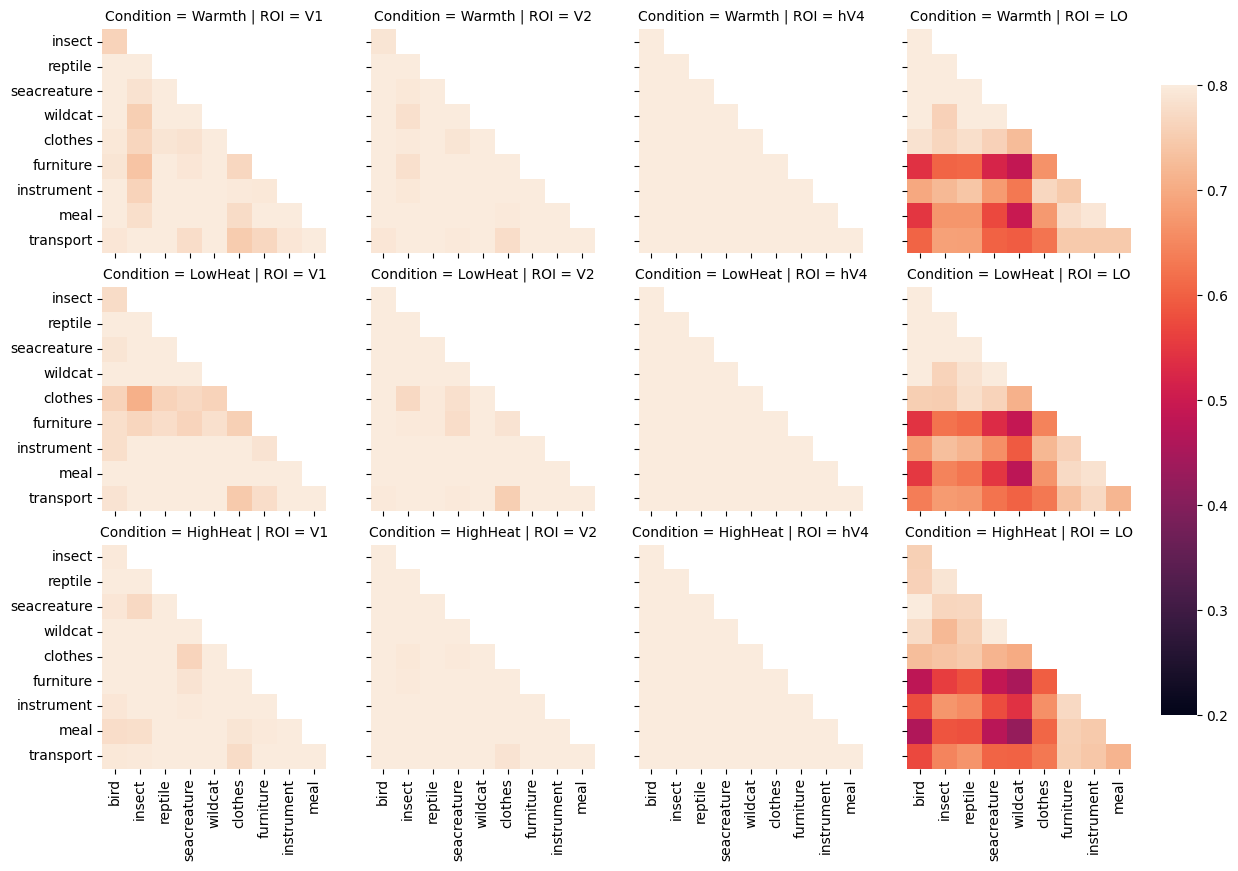

In [18]:
# Plotting
save_figure = 0
fig_type = 'heatmap' #'heatmap' # 'main_btw', 


if fig_type == 'main_btw':
    dat_to_plot = btw_corr_df_mean
    cols = ["#fee0d2", "#fc9272", "#de2d26"]
    title = "Between-category similarity"
    ax = sns.boxplot(data=dat_to_plot, x="ROI", y="corr_btw",
                    hue="Condition", showcaps=False,
                    flierprops={"marker":""},
                    palette= cols, order=rois, hue_order=cond_names)  
    sns.stripplot(data=dat_to_plot, x="ROI", y="corr_btw",
                  hue="Condition", dodge=True,palette=cols,linewidth=0.5,edgecolor='gray', order=rois,hue_order=cond_names) 
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[0:3], labels[0:3], bbox_to_anchor=(1.05,1), loc=2, borderaxespad=0.)
    ax.set_title(title)
    ax.set_ylabel("Similarity (Pearson's r)")
    fig = ax.get_figure()
    sns.despine()

    if save_figure:
        fig.savefig(os.path.join(figdir, f'pacman_240306_mni_rsa_{roi_type}_{fig_type}.pdf'), bbox_inches='tight')     
        
elif fig_type == 'heatmap':
    dat_to_plot = df_heat
    def draw_heatmap(*args,**kwargs):
        data = kwargs.pop('data')
        d = data.pivot_table(index=args[1], columns=args[0],values=args[2], sort=False)
        sns.heatmap(d, **kwargs)

    g = sns.FacetGrid(dat_to_plot, col='ROI', col_order=rois, row = 'Condition', row_order = cond_names) #, row = 'Condition', row_order = condition

    cbar_ax = g.fig.add_axes([1, .2, .03, .7])
    g = g.map_dataframe(draw_heatmap, 'Category1', 'Category2', 'corr_btw',annot=False, vmin=0.2, vmax=0.8,cbar_ax=cbar_ax, square=True)

    g.set_axis_labels('','')

    if save_figure:
        plt.savefig(os.path.join(figdir, f'pacman_240306_mni_rsa_{roi_type}_{fig_type}.pdf'), bbox_inches='tight')

In [19]:
# Stats

type_anova='post' # 2, post


dat_to_test = btw_corr_df_mean
field_values = 'corr_btw'
if type_anova == 2:
    # two-way anova
    
    model = ols(f'{field_values}~ C(ROI) + C(Condition)+ C(ROI):C(Condition)', dat_to_test).fit() 
    
    aov_table = sm.stats.anova_lm(model, typ=2)
    aov_table['mean_sq'] = aov_table['sum_sq'] / aov_table['df']
    SS_total = aov_table['sum_sq'].sum() + model.ssr
    total_row = pd.DataFrame({
    'sum_sq': [SS_total],
    'df': [aov_table['df'].sum() + model.df_resid],
    'mean_sq': [None],
    'F': [None],
    'PR(>F)': [None]
    }, index=['Total'])

    # Append the total row to the ANOVA table
    anova_complete = pd.concat([aov_table, total_row])
    #print(f'{var}')
    anova_complete 

elif type_anova == 'post':
    tukey = pairwise_tukeyhsd(dat_to_test[field_values], dat_to_test['ROI'])
    print(tukey)
    print('Exact p-values')
    print(tukey.pvalues)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    LO     V1   0.1185    0.0  0.0651 0.1719   True
    LO     V2   0.1368    0.0  0.0834 0.1903   True
    LO    hV4   0.1904    0.0   0.137 0.2439   True
    V1     V2   0.0184 0.8121 -0.0351 0.0718  False
    V1    hV4    0.072 0.0031  0.0185 0.1254   True
    V2    hV4   0.0536 0.0488  0.0002  0.107   True
---------------------------------------------------
Exact p-values
[1.17794473e-07 6.83665125e-10 2.68896017e-13 8.12078797e-01
 3.14895170e-03 4.87990664e-02]
